# Dimensionality reduction: PCA and MDS on neural data

**NS5007 Human and Artificial Intelligence · lab notebook**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qihongl/NS5007/blob/main/pca_mds.ipynb)

Neural recordings are high-dimensional: hundreds of voxels or thousands of neurons, each one a dimension. The interesting structure — *what* the brain represents — usually lives in far fewer dimensions than that. Today we build two of the classic tools for exposing it:

- **PCA** (Principal Component Analysis) rotates the data onto its own main axes of variance.
- **MDS** (Multi-Dimensional Scaling) starts from pairwise distances alone and places every item on a 2D map that respects those distances.

We start with toy data you can picture in your head, then apply both methods to two real datasets:

1. **IT cortex responses to 92 everyday images**, human fMRI + monkey single-cell ([Kriegeskorte et al., 2008](https://doi.org/10.1016/j.neuron.2008.10.043)) — the dataset that launched representational similarity analysis (RSA).
2. **Hippocampal fMRI during sequences with temporal community structure** ([Schapiro et al., 2013](https://doi.org/10.1038/nn.3331)) — data from [OpenNeuro ds001621](https://openneuro.org/datasets/ds001621), preprocessed offline (despiking, motion correction, normalization) and packaged per region; `make_week5_derived_data.py` documents every step. Note the twist: the 2013 searchlight results are cortical, and we will test the hippocampal intuition as a control.

**Learning goals.** After this lab you can (i) run PCA and read scree plots and projections, (ii) build an RDM and embed it with MDS, (iii) say when one method beats the other, and (iv) go from raw BIDS fMRI to an embedding of stimulus codes.

About 5–10 minutes end-to-end on Colab — the fMRI preprocessing was done offline and the packaged pattern data (~15 MB, `data/`) loads instantly. All exercises have solutions hidden at the bottom.

> **Colab:** open with the badge above (notebook + data live in the course GitHub repo), or upload the notebook and the `data/` folder manually. The §5 cell fetches the packaged fMRI patterns automatically.


In [1]:
import os, sys, time, importlib.util, subprocess, urllib.request

for mod_name, pip_name in [('numpy', 'numpy'), ('scipy', 'scipy'),
                           ('matplotlib', 'matplotlib'), ('pandas', 'pandas'),
                           ('sklearn', 'scikit-learn')]:
    if importlib.util.find_spec(mod_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.spatial.distance import squareform, pdist
from scipy.stats import spearmanr, rankdata, ttest_1samp
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, Isomap

np.random.seed(42)
mpl.rcParams['figure.dpi'] = 110

DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

def run_mds(D, precomputed=False, seed=42):
    '''2-D MDS with pinned settings. Every MDS call goes through here so the
    pending scikit-learn API change (the `dissimilarity` kwarg is deprecated,
    removal slated for 1.10) is a one-line migration, and no FutureWarnings spam
    the output for students.'''
    import warnings
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=FutureWarning)
        return MDS(n_components=2,
                   dissimilarity='precomputed' if precomputed else 'euclidean',
                   n_init=4, random_state=seed,
                   normalized_stress='auto').fit_transform(D)

def fetch(url, dest):
    '''Download url -> dest, skip if already there.'''
    if os.path.exists(dest):
        print(f'cached: {dest}')
        return dest
    t0 = time.time()
    with urllib.request.urlopen(url) as r, open(dest, 'wb') as f:
        while True:
            chunk = r.read(1 << 22)
            if not chunk:
                break
            f.write(chunk)
    print(f'downloaded {dest} ({os.path.getsize(dest)/1e6:.1f} MB, {time.time()-t0:.0f}s)')
    return dest

rng = np.random.default_rng(42)
COMMUNITY_COLOR = {'A': '#4C72B0', 'B': '#DD8452', 'C': '#55A868'}

def plot_embedding(xy, labels, title='', ax=None):
    '''Scatter an embedding colored by community letter; boundary nodes get black rings.'''
    ax = ax or plt.gca()
    for lab, (x, y) in zip(labels, xy):
        c = COMMUNITY_COLOR[lab[0]]
        edge = 'k' if lab[1] in ('1', '5') else c      # boundary nodes end in 1 or 5
        ax.scatter(x, y, s=90, color=c, edgecolor=edge, linewidth=2.6, zorder=3)
        ax.annotate(lab, (x, y), textcoords='offset points',
                    xytext=(7, 4), fontsize=9, zorder=4)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    return ax

print('ready')


ready


## 1. Why reduce dimensions?

A recording session gives you a data matrix: rows are conditions/items, columns are features (voxels, neurons, pixels). Measuring 674 neurons puts every image at a point in **674-dimensional space** — no direct way to look at that.

Two complementary questions orient any reduction:

- *Which directions carry the most signal?* → **PCA**
- *How far apart are my conditions?* → **MDS**

Both hand back a few axes we can actually plot and interpret.

## 2. Toy example 1 — three clusters hiding in 10 dimensions

We build three clusters that truly live on a 2D plane (plus noise sprinkled across 8 irrelevant dimensions), then forget their true shape and let PCA rediscover it.

The algorithm has no magic in it: center the data, take the eigenvectors of the covariance matrix ordered by eigenvalue, project. Each eigenvalue *is* the variance along its eigenvector.

In [2]:
def make_blobs(n_per=60, n_dims=10, seed=42):
    rng = np.random.default_rng(seed)
    centers = np.array([[0., 0.], [6., 3.], [-2., 7.]])       # separated on a plane
    pts2d = np.repeat(centers, n_per, axis=0) \
            + rng.normal(scale=1.0, size=(n_per*3, 2))
    W = rng.normal(size=(2, n_dims))                           # random mixing matrix
    X = pts2d @ W + rng.normal(scale=1.5, size=(n_per*3, n_dims))
    y = np.repeat([0, 1, 2], n_per)
    return X, y

X_blob, y_blob = make_blobs()
CLS_COLORS = ['#4C72B0', '#DD8452', '#55A868']
print(X_blob.shape, '<- (samples, features)')

(180, 10) <- (samples, features)


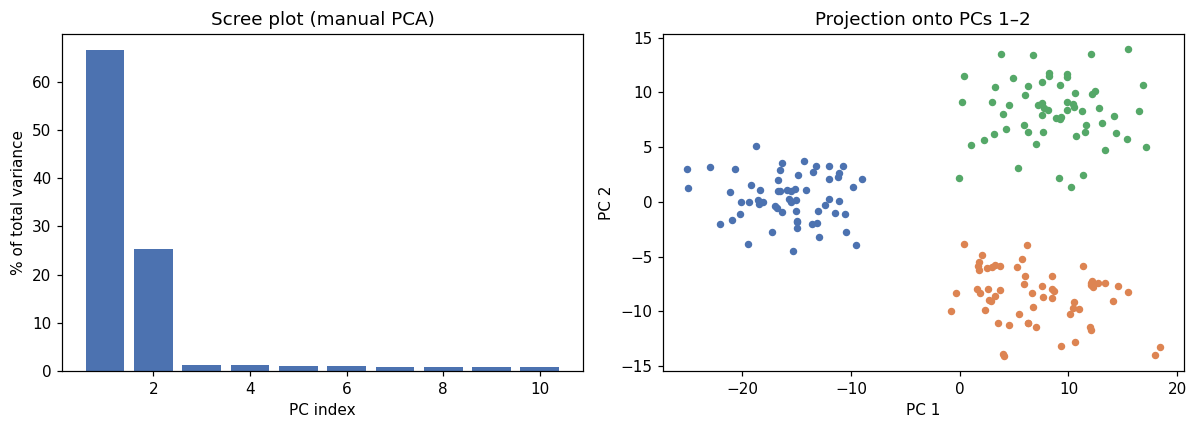

In [3]:
# --- PCA step by step -------------------------------------------------
X_c   = X_blob - X_blob.mean(axis=0)          # 1. center
C     = np.cov(X_c, rowvar=False)             # 2. covariance
eigval, eigvec = np.linalg.eigh(C)            # 3. eigendecomposition
order = np.argsort(eigval)[::-1]              # eigh sorts ascending -> flip
eigval, eigvec = eigval[order], eigvec[:, order]

scores = X_c @ eigvec                         # PC scores = projected data

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(np.arange(1, 11), eigval / eigval.sum() * 100, color='#4C72B0')
axes[0].set(xlabel='PC index', ylabel='% of total variance',
            title='Scree plot (manual PCA)')
for k in range(3):
    sel = y_blob == k
    axes[1].scatter(scores[sel, 0], scores[sel, 1], s=15, color=CLS_COLORS[k])
axes[1].set(xlabel='PC 1', ylabel='PC 2', title='Projection onto PCs 1–2')
plt.tight_layout();

Variance collapses after PC 2 — that's our hidden 2D manifold announcing itself. PCA recovered the plane without ever being told.

Same thing with scikit-learn, plus a cumulative-variance view:

manual vs sklearn eigenvalues agree? True


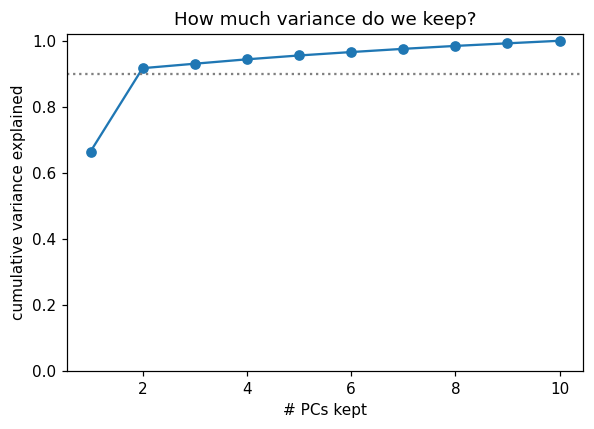

In [4]:
pca = PCA(n_components=10).fit(X_blob)        # sklearn centers internally
check = pca.explained_variance_ - eigval
print('manual vs sklearn eigenvalues agree?', np.allclose(check, 0))

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(np.arange(1, 11), pca.explained_variance_ratio_.cumsum(), 'o-')
ax.set(xlabel='# PCs kept', ylabel='cumulative variance explained',
       title='How much variance do we keep?')
ax.axhline(0.9, ls=':', c='gray'); ax.set_ylim(0, 1.02)
plt.tight_layout();

### Exercise 1

(a) What fraction of total variance do the first two PCs capture? Fill in one line below.

(b) Rotations/reflections within the recovered plane are legal for PCA — PC 1 won't necessarily point along the *original* latent axes the data was built from. Still, geometry is preserved: verify that pairwise distances between samples are essentially unchanged after dropping down to those 2 PCs.

In [5]:
var_first_two = None    # TODO (a): fraction of total variance in PCs 1+2
                        # hint: pca.explained_variance_ratio_ is a vector of fractions

pcs_2d    = None        # TODO (b): first two columns of the projection
D_before  = pdist(X_blob)
if var_first_two is None or pcs_2d is None:
    print('(fill the TODOs above, then rerun this cell)')
else:
    D_after = pdist(pcs_2d)
    print(f'first two PCs capture {var_first_two:.1%} of variance | '
          f'distance agreement r = {np.corrcoef(D_before, D_after)[0,1]:.3f}')

(fill the TODOs above, then rerun this cell)


## 3. Toy example 2 — a rolled sheet: what variance misses

PCA hunts for straight axes of maximal variance. On a curved manifold that strategy has a blind spot: a projection can flatten the sheet and fold distant parts on top of each other. Rather than assert it, build a roll you can picture — a sheet of paper curled into about two turns — and watch what each method does with it.


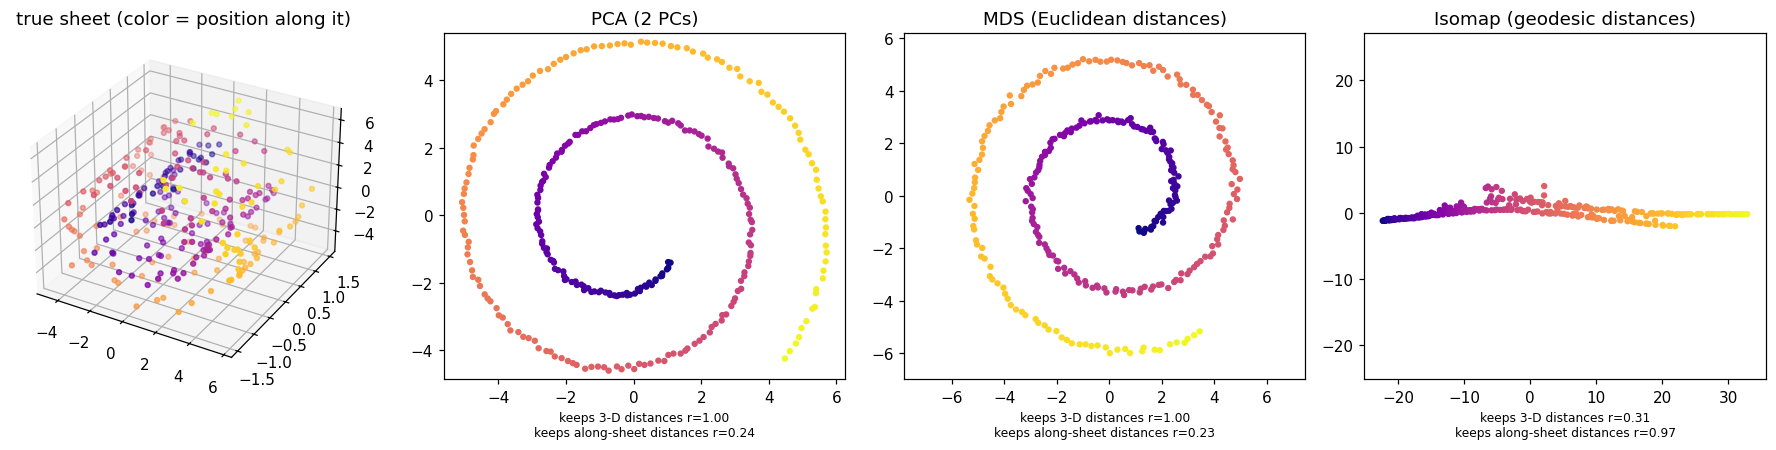

In [6]:
# a rolled-up sheet: a 2-D sheet curled into a roll, living in 3-D
rng_roll = np.random.default_rng(42)
t = np.linspace(np.pi/2, np.pi/2 + 4*np.pi, 300)   # position along the sheet (~2 turns)
r = 1.2 + 0.35 * t                                  # coil radius -> adjacent coils ~2.2 apart
v = rng_roll.uniform(-1.5, 1.5, 300)                # width of the sheet
X_roll = np.c_[r * np.cos(t), v, r * np.sin(t)]
X_roll += rng_roll.normal(scale=0.03, size=X_roll.shape)   # measurement noise

D_along = pdist(np.c_[t, np.zeros_like(t)])         # distance measured ALONG the sheet

pca2     = PCA(2).fit_transform(X_roll)
emb_euc  = run_mds(X_roll)                          # MDS on Euclidean distances
iso_roll = Isomap(n_components=2).fit_transform(X_roll)   # MDS on geodesic distances

fig = plt.figure(figsize=(16.5, 4.2))
ax = fig.add_subplot(141, projection='3d')
ax.scatter(*X_roll.T, c=t, cmap='plasma', s=10)
ax.set_title('true sheet (color = position along it)')

panels = [(pca2, 'PCA (2 PCs)'),
          (emb_euc, 'MDS (Euclidean distances)'),
          (iso_roll, 'Isomap (geodesic distances)')]
for k, (E, ttl) in enumerate(panels):
    plt.subplot(1, 4, k + 2)
    plt.scatter(E[:, 0], E[:, 1], c=t, cmap='plasma', s=10)
    plt.title(ttl); plt.axis('equal')
    r3  = np.corrcoef(pdist(E), pdist(X_roll))[0, 1]
    ral = np.corrcoef(pdist(E), D_along)[0, 1]
    plt.xlabel(f'keeps 3-D distances r={r3:.2f}\nkeeps along-sheet distances r={ral:.2f}',
               fontsize=8)
plt.tight_layout();


Read the r-labels under each panel. PCA and Euclidean-distance MDS both reproduce the sheet's 3-D distances almost perfectly (r ≈ 1.0) — and both mangle the geometry that matters, the distances *along* the sheet (r ≈ 0.23): the two turns of the roll land on top of each other. This is not MDS underperforming — the closed form below proves that on Euclidean distances classical MDS *is* PCA. Distances cannot be preserved better than Euclidean geometry allows; what changes the picture is changing *which* distances you ask for. Isomap asks for geodesic (along-the-sheet) distances and unrolls the roll (r ≈ 0.97).

Notice what MDS needed as input: *only a matrix of pairwise distances*, never the raw data. That is exactly the currency neuroscience often trades in — instead of trusting every individual neuron or voxel, we trust **how similar** two response patterns are. Pairwise dissimilarities between conditions get a name and their own picture: the **representational dissimilarity matrix (RDM)**. And the lesson travels with it: the distance you feed an RDM is a modelling decision.


### Classical MDS, by hand

Classical (Torgerson) MDS — the metric variant with a closed form — is worth seeing once:
1. Square the distance matrix: $\mathbf{D}$ → $\mathbf{D}^{\circ 2}$.
2. Double-center it: $\mathbf{B} = -\tfrac{1}{2}\mathbf{J}\mathbf{D}^{\circ 2}\mathbf{J}$ with $\mathbf{J}=\mathbf{I}-\frac{1}{n}\mathbf{1}\mathbf{1}^\top$. $\mathbf{B}$ is the Gram matrix (inner products) of the centered points.
3. Take the top eigenvectors of $\mathbf{B}$, scaled by $\sqrt{\lambda}$. Done.

For Euclidean distances this provably equals PCA — different machinery, same geometry — which is exactly why the two middle panels folded the roll identically.

In [7]:
def classical_mds(D, k=2):
    '''Classical MDS from a square distance matrix -> k-D coordinates.'''
    D2 = D ** 2
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J                     # double-centered Gram matrix
    lam, V = np.linalg.eigh(B)
    top = np.argsort(lam)[::-1][:k]
    return V[:, top] * np.sqrt(np.clip(lam[top], 0, None))  # clip: non-Euclidean RDMs can give small negative eigenvalues

# check ours on the rolled sheet
D_roll = squareform(pdist(X_roll))
own  = classical_mds(D_roll, 2)
pca2 = PCA(2).fit_transform(X_roll)
skl  = run_mds(D_roll, precomputed=True, seed=1)   # sklearn's iterative SMACOF variant
for other, name in [(pca2, 'PCA'), (skl, 'sklearn SMACOF')]:
    r_pairs = [round(float(abs(np.corrcoef(own[:, i], other[:, j])[0, 1])), 2)
               for i in range(2) for j in range(2)]
    print(f'classical MDS vs {name} (rotation/reflection allowed):', r_pairs)
# PCA matches exactly (the cell-13 theorem). SMACOF lands near but not at the
# classical solution: it minimizes raw stress, a slightly different criterion --
# a reminder that "MDS" names a family of methods, not one algorithm.


classical MDS vs PCA (rotation/reflection allowed): [1.0, 0.0, 0.0, 1.0]
classical MDS vs sklearn SMACOF (rotation/reflection allowed): [0.81, 0.64, 0.58, 0.77]


### Exercise 2 — swap the metric, recover the map

The RDM recipe is a design decision, and it decides what your map is about. To see it in isolation: twelve "conditions" were measured in 200 "voxels". Every condition's true pattern is a large shared template plus a small group-specific structure (3 groups, 4 conditions each) — but each condition was recorded with its own scanner gain, a single multiplicative factor between 0.5× and 3×, exactly what happens when you compare sessions scanned on two days.

Run the starter: it builds the Euclidean-distance RDM of the raw patterns and embeds it twice, colored by group and by gain. Then replace the Euclidean RDM with a correlation-based one (hint: z-score each row of `P_gain` before calling `pdist` — that makes the distance scale-free) and rerun. Describe what changes, then answer: which metric would you prefer for fMRI voxel patterns collected on two days where scanner gain drifted between sessions, and why?


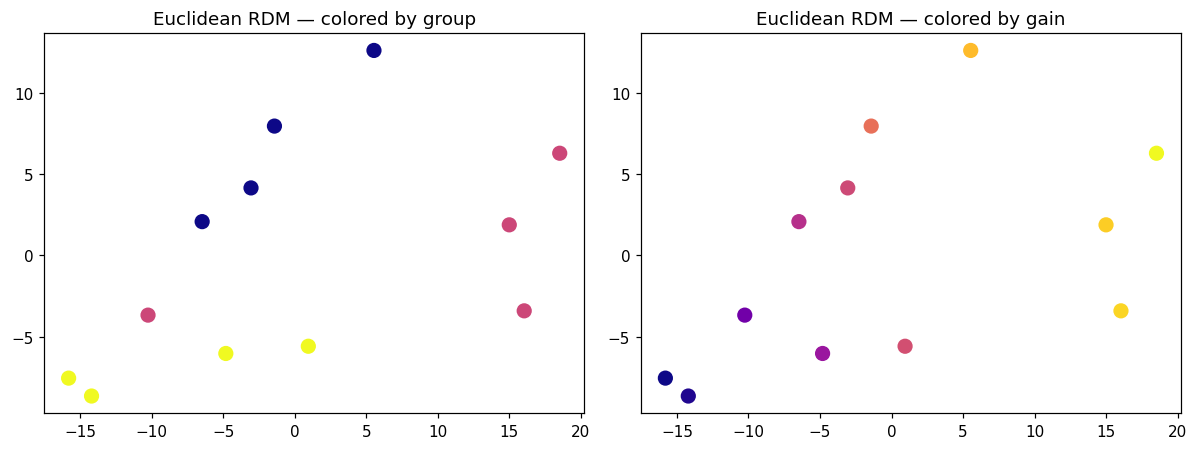

In [8]:
# Starter: Euclidean distances between the raw patterns (run it, then swap the metric)
rng_ex    = np.random.default_rng(7)
n_cond, n_vox = 12, 200
group_of  = np.repeat([0, 1, 2], 4)                   # 3 groups, 4 conditions each
templates = rng_ex.normal(size=(3, n_vox))            # group-specific structure
shared    = rng_ex.normal(size=n_vox)                 # large template every condition shares
true_pats = shared[None, :] + 0.3 * templates[group_of] \
            + rng_ex.normal(scale=0.2, size=(n_cond, n_vox))
gain      = rng_ex.uniform(0.5, 3.0, n_cond)          # per-condition scanner gain
P_gain    = true_pats * gain[:, None]                 # what the 'scanner' hands you

S_euc = squareform(pdist(P_gain))                     # TODO: swap for a correlation-based RDM:
                                                      #       z-score each row of P_gain, then
                                                      #       pdist again
emb_ex = run_mds(S_euc, precomputed=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, col, lab in [(axes[0], group_of, 'colored by group'),
                     (axes[1], gain, 'colored by gain')]:
    ax.scatter(emb_ex[:, 0], emb_ex[:, 1], c=col, cmap='plasma', s=80)
    ax.set_title(f'Euclidean RDM — {lab}')
plt.tight_layout();


## 4. Real data I — human and monkey IT: Kriegeskorte et al. 2008

Time for real neural data. Kriegeskorte and colleagues showed the same 92 photographs — faces, bodies, houses, tools, fruits — while measuring responses in human IT cortex (fMRI) and monkey IT (674 single neurons). They compared *response patterns*: the full vector of activity each image evokes. Their summary statistic was correlation distance between pairs of images, displayed as a 92×92 RDM — color-coded, in their figures, by each RDM's own **percentile ranks** rather than raw values (more on that below).

That framing became **RSA**, and it begins exactly where §3 ended: distances first, geometry second.

The official supplement is mirrored in the [rsatoolbox repository](https://github.com/rsagroup/rsatoolbox/tree/master/demos/92imageData) (data © Kriegeskorte et al., shared for research/teaching).

In [9]:
K_URL = ('https://raw.githubusercontent.com/rsagroup/rsatoolbox/master/'
         'demos/92imageData/')
KG_DIR = os.path.join(DATA_DIR, 'kriegeskorte92')
os.makedirs(KG_DIR, exist_ok=True)

sup_mat  = fetch(K_URL + 'Kriegeskorte_Neuron2008_supplementalData.mat',
                 os.path.join(KG_DIR, 'supplemental.mat'))
brain_mat = fetch(K_URL + '92_brainRDMs.mat', os.path.join(KG_DIR, 'brainRDMs.mat'))
model_mat = fetch(K_URL + '92_modelRDMs.mat', os.path.join(KG_DIR, 'modelRDMs.mat'))

cached: data/kriegeskorte92/supplemental.mat
cached: data/kriegeskorte92/brainRDMs.mat
cached: data/kriegeskorte92/modelRDMs.mat


In [10]:
sup      = sio.loadmat(sup_mat)
brain    = sio.loadmat(brain_mat)
models_raw = sio.loadmat(model_mat)

images   = [st['image'] for st in sup['stimuli_92objs'][0]]         # the 92 photos
cat_str  = [str(np.squeeze(st['category'])) for st in sup['stimuli_92objs'][0]]
cat_lbls = [str(np.squeeze(c)) for c in sup['categoryLabels'][0]]
cat_vec  = sup['categoryVectors'].astype(bool)                      # 92 x 12 indicators
print('category labels:', cat_lbls)

# human IT: average the four subjects x two sessions
hIT_rdm = np.mean([brain['RDMs'][0, i, j]['RDM']
                   for i in range(4) for j in range(2)], axis=0).astype(float)

# monkey IT: stored as condensed upper triangle (C(92,2)=4186 pairs)
iu  = np.triu_indices(92, 1)
mit_condensed = np.squeeze(sup['RDMs_mIT_hIT_fig1'][0][0]['RDM']).astype(float)
mIT_rdm = np.zeros((92, 92)); mIT_rdm[iu] = mit_condensed; mIT_rdm += mIT_rdm.T

model_rdms = {str(m['name'][0]): np.asarray(m['RDM'], dtype=float)
              for m in models_raw['Models'][0]}
print('hIT', hIT_rdm.shape, '| mIT reconstructed:', mIT_rdm.shape,
      '| models:', list(model_rdms)[:4], '...')

category labels: ['animate', 'inanim', 'human', 'nonhumani', 'body', 'face', 'natObj', 'artiObj', 'rand24', 'rand48', 'other48', 'monkeyape']
hIT (92, 92) | mIT reconstructed: (92, 92) | models: ['animacy', 'FaceBodyManmadeNatobj', 'monkeyIT', 'EVA'] ...


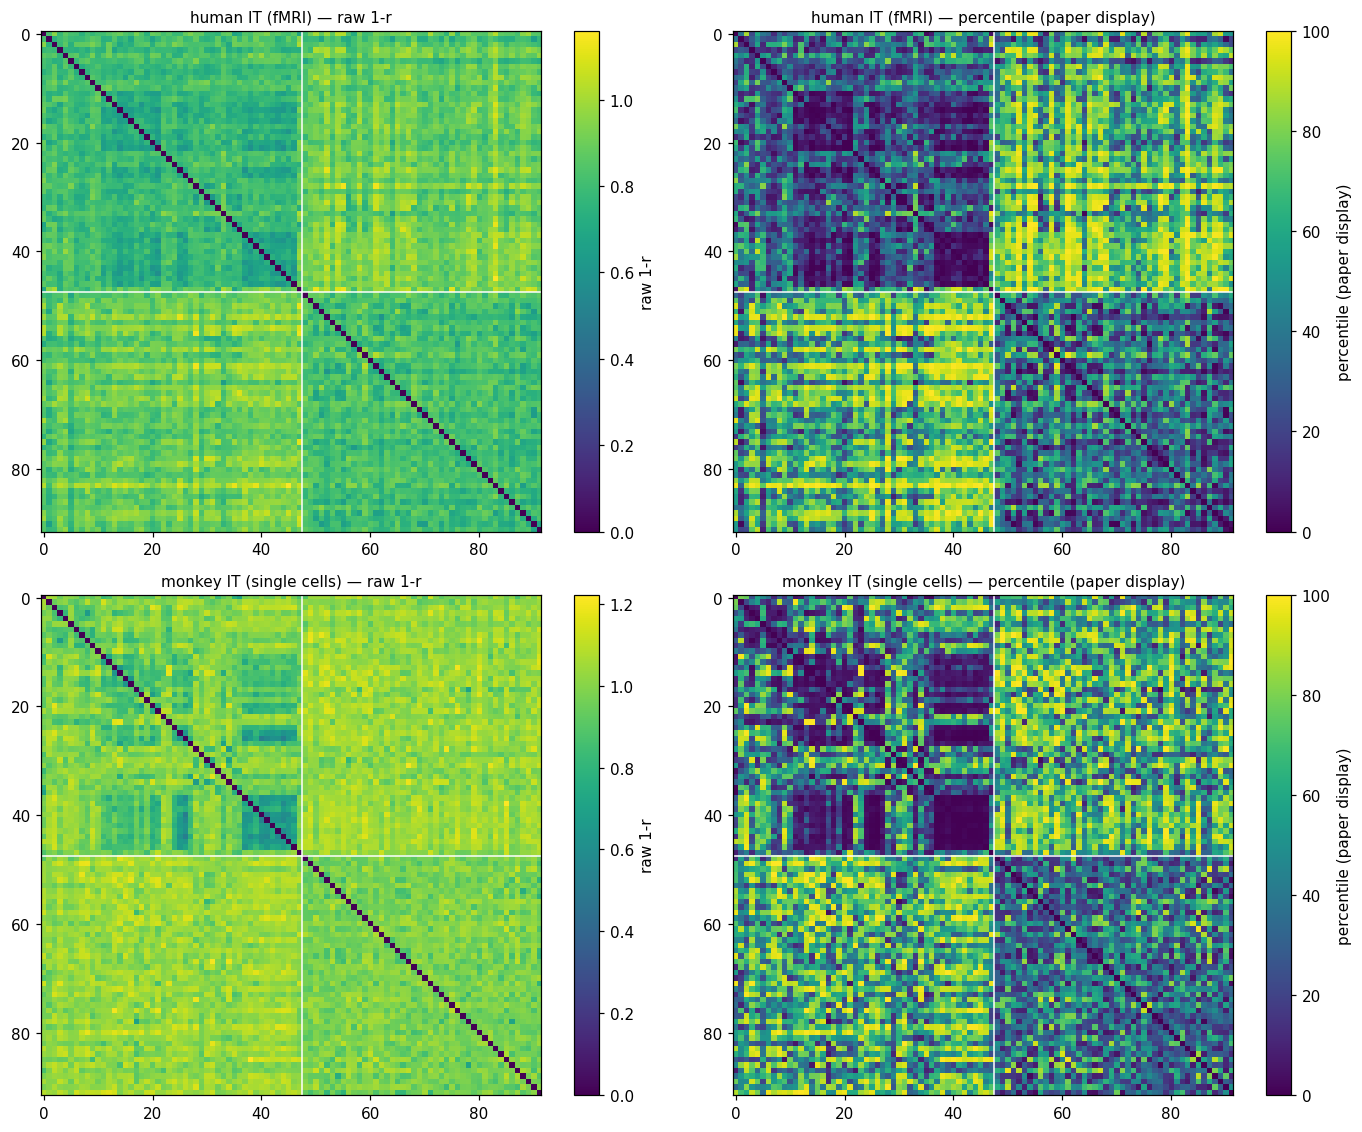

In [11]:
# --- display choice matters: the paper color-codes each RDM by percentiles ---
# Kriegeskorte et al. 2008 (Figs 1 & 5): "The color code reflects percentiles
# (see color bar) computed separately for each RDM". Mapping each RDM's 1-r
# values onto its own rank scale stretches the display across the full colormap,
# which makes the animate-inanimate block contrast look crisper than the raw
# values alone would. Statistics and MDS below still use the raw 1-r values --
# in the paper too, percentiles were a display-only transformation.
def percentile_rdm(rdm):
    '''Each dissimilarity -> its percentile among that RDM's upper-triangle values (0-100).'''
    p = rankdata(rdm[iu]) / len(iu[0]) * 100
    P = np.zeros_like(rdm)
    P[iu] = p
    P += P.T
    return P

sort_idx = np.argsort(cat_vec.argmax(axis=1))

fig, axes = plt.subplots(2, 2, figsize=(13, 10.4))
for row, (ttl, rdm) in enumerate([('human IT (fMRI)', hIT_rdm),
                                  ('monkey IT (single cells)', mIT_rdm)]):
    for col, (M, clab) in enumerate([(rdm, 'raw 1-r'),
                                     (percentile_rdm(rdm), 'percentile (paper display)')]):
        ax = axes[row, col]
        im = ax.imshow(M[np.ix_(sort_idx, sort_idx)], cmap='viridis')
        cat_of_sorted = cat_vec.argmax(axis=1)[sort_idx]
        for b in np.where(np.diff(cat_of_sorted) != 0)[0] + 0.5:
            ax.axvline(b, color='w', lw=1); ax.axhline(b, color='w', lw=1)
        ax.set_title(f'{ttl} — {clab}', fontsize=10)
        cb = plt.colorbar(im, ax=ax, fraction=.046); cb.set_label(clab)
plt.tight_layout();

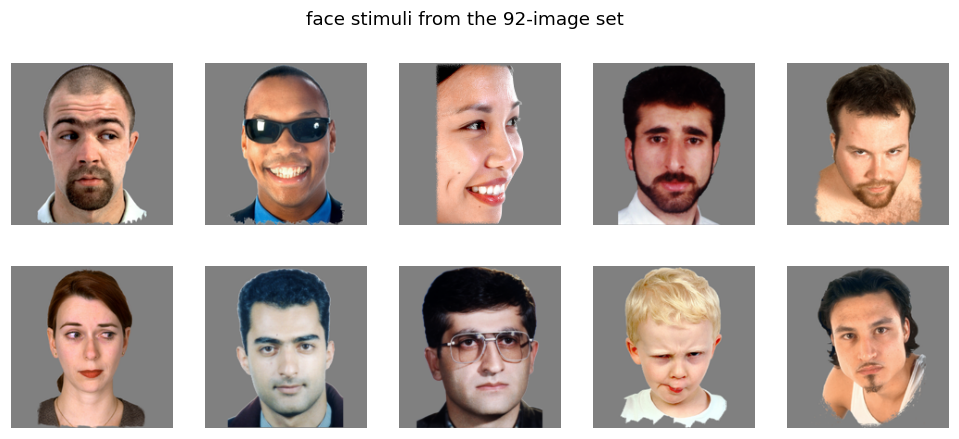

In [12]:
# a sample of the actual stimuli behind these matrices
face_ids = np.where(cat_vec[:, cat_lbls.index('face')])[0][:10]
fig, axes = plt.subplots(2, 5, figsize=(11, 4.4))
for ax, i in zip(axes.ravel(), face_ids):
    ax.imshow(images[i]); ax.axis('off')
fig.suptitle('face stimuli from the 92-image set');

Bright blocks reappear at matching positions in the two species' matrices — that visual resemblance *is* the claim of the paper. Next we quantify it.

**A display caveat worth internalizing.** In the right-hand column each RDM is shown the way the paper showed theirs: color-coding each RDM's 1 − r values by *within-RDM percentiles* (their Figure 1/5 legends: *"The color code reflects percentiles … computed separately for each RDM"*). Because percentiles by construction spread uniformly across the colormap, this stretches the display's dynamic range and makes the animate–inanimate block contrast look maximally crisp — the raw 1 − r histograms (their Figs. 3A/6) show the actual, positively-skewed spread. The transformation is display-only: the paper's MDS and statistics use the raw 1 − r values, and so does every analysis below.

In [13]:
def rdm_within_between(rdm, mask_bool):
    '''Mean dissimilarity among same-group vs cross-group image pairs.'''
    a = rdm[iu]; same = mask_bool[iu[0]] == mask_bool[iu[1]]
    return a[same].mean(), a[~same].mean()

mask_face  = cat_vec[:, cat_lbls.index('face')]
within_f   = None   # TODO: fill with the first output of rdm_within_between(...)
between_f  = None   # TODO: ...and the second output
if within_f is None:
    print('(complete both TODOs, then rerun)')
else:
    print(f'within-faces: {within_f:.3f} | faces vs rest: {between_f:.3f}')

(complete both TODOs, then rerun)


### From RDMs to maps — MDS embeddings of both species

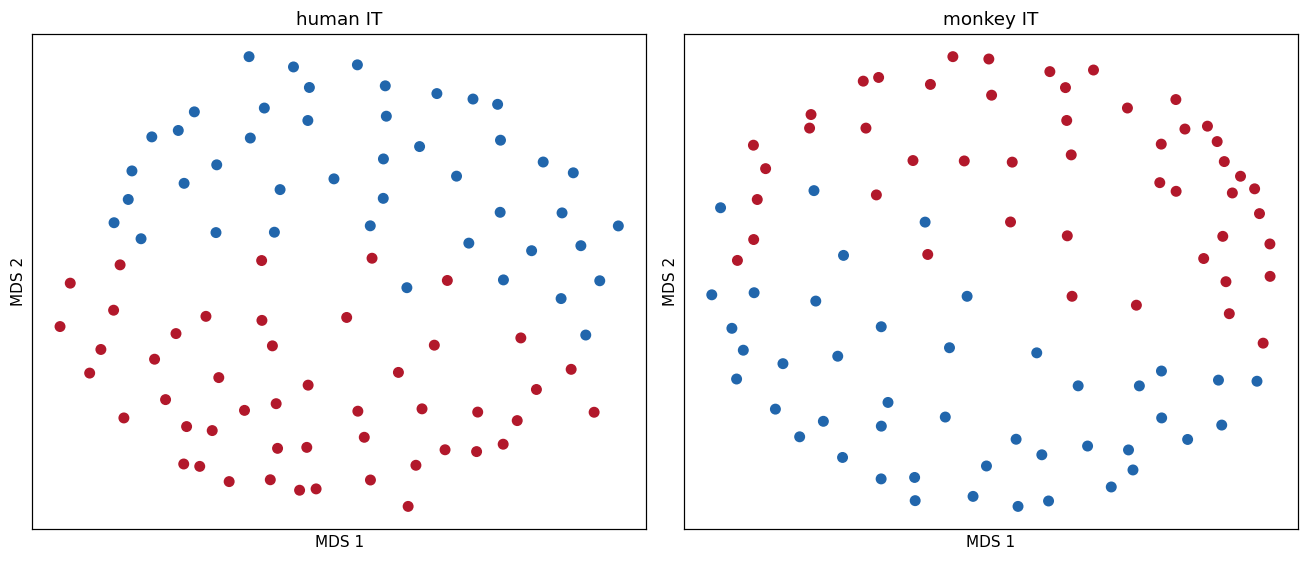

In [14]:
mds_hum = run_mds(hIT_rdm, precomputed=True)
mds_mon = run_mds(mIT_rdm, precomputed=True)

# color by coarse grouping (paper Fig. 2 style)
group = np.where((cat_vec[:, cat_lbls.index('human')] |
                  cat_vec[:, cat_lbls.index('nonhumani')]), '#b2182b',   # animate-ish
                 np.where(cat_vec[:, cat_lbls.index('inanim')], '#2166ac',  # inanimate
                          '#888888'))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, emb, ttl in [(axes[0], mds_hum, 'human IT'), (axes[1], mds_mon, 'monkey IT')]:
    ax.scatter(emb[:, 0], emb[:, 1], c=group, s=38)
    ax.set(title=ttl, xlabel='MDS 1', ylabel='MDS 2')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout();

# what do we even gain from MDS here? the RDM *is* the geometry — this just makes it drawable.

Red = animate conditions (human and non-human bodies and faces), blue = inanimate objects. Bodies and faces attract each other; tools drift off — and the topology repeats across species, an ocean apart (the human fMRI was collected at NIH in Bethesda, the monkey recordings at RIKEN in Japan).

### Exercise 4 — mini-RSA: which model explains human IT?

RSA compares RDMs by correlating their upper triangles. Complete the loop to Spearman-correlate the human-IT RDM against every model RDM plus monkey IT, rank the results, and interpret: which model tracks human IT best? Where does low-level V1 sit relative to IT-style representations — and why is that gap informative?

In [15]:

targets = dict(model_rdms)
targets['monkey IT (this dataset)'] = mIT_rdm
rsa_scores = {}
for name, rdm in targets.items():
    pass  # placeholder so the loop parses; delete it when you uncomment below
    # rsa_scores[name] = spearmanr(hIT_rdm[iu], rdm[iu]).statistic
    # TODO: uncomment the line above — that's the whole exercise. Then:
    # - which model tops the table, and is monkey IT close behind hIT itself?
    # - where do V1/Silhouette (image-level models) land relative to animacy/FaceBody models?

if rsa_scores:
    pd.Series(rsa_scores).sort_values().plot.barh(color='#4C72B0', figsize=(7, 4.5))
    plt.axvline(0, c='k', lw=.6)
    plt.xlabel(r'Spearman $\rho$ with human IT RDM')
    plt.title('Model–brain similarity (mini-RSA)')
else:
    print('(uncomment the statistic line above to produce the ranking)')

(uncomment the statistic line above to produce the ranking)


Sanity note: exclude `hIT_rdm` itself from `targets` — correlating a matrix with itself returns ρ = 1 and adds nothing. Expect species and categorical models near the top, Silhouette/V1-type image models near zero.

## 5. Real data II — events carved out of experience: Schapiro et al. 2013

Second dataset: not static images but **streams of experience**. Participants passively viewed long sequences of 15 abstract objects whose transition probabilities followed the graph below: three communities (A, B, C) internally well connected, chained together by rare "bridge" links. Does the brain start treating co-experienced items as belonging to *events*?

The paper shows that neural activity patterns formed community structure. They made their data public at OpenNeuro [ds001621](https://openneuro.org/datasets/ds001621)! Let's take a look!



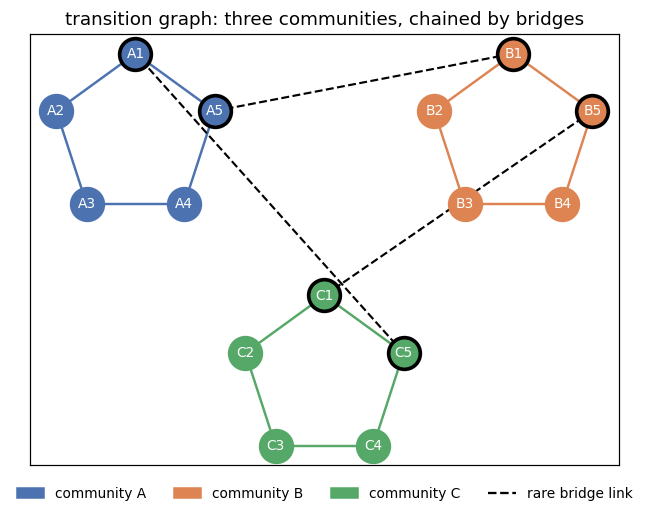

In [16]:
# the community structure: three densely connected communities (A, B, C), chained
# by rare 'bridge' links between boundary nodes (schematic; black rings mark the
# boundary nodes, which also carry the bridge links).
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(6.4, 5.4))
ang = np.linspace(0, 2*np.pi, 6)[:-1] + np.pi/2
centers = {'A': (-1.25, 0.55), 'B': (1.25, 0.55), 'C': (0.0, -1.05)}
pos = {f'{c}{i}': (centers[c][0] + 0.55*np.cos(a), centers[c][1] + 0.55*np.sin(a))
       for c in 'ABC' for i, a in zip(range(1, 6), ang)}
for c in 'ABC':
    for i in range(1, 6):
        p, q = pos[f'{c}{i}'], pos[f'{c}{i % 5 + 1}']
        ax.plot([p[0], q[0]], [p[1], q[1]], color=COMMUNITY_COLOR[c], lw=1.6, zorder=1)
for a, b in [('A5', 'B1'), ('B5', 'C1'), ('C5', 'A1')]:
    p, q = pos[a], pos[b]
    ax.plot([p[0], q[0]], [p[1], q[1]], color='k', lw=1.4, ls='--', zorder=1)
for node, (x, y) in pos.items():
    ring = 'k' if node[1] in ('1', '5') else COMMUNITY_COLOR[node[0]]
    ax.scatter(x, y, s=430, color=COMMUNITY_COLOR[node[0]], edgecolor=ring,
               linewidth=2.4, zorder=3)
    ax.annotate(node, (x, y), ha='center', va='center', fontsize=9, color='w', zorder=4)
ax.legend(handles=[mpatches.Patch(color=COMMUNITY_COLOR[c], label=f'community {c}') for c in 'ABC']
                   + [plt.Line2D([], [], color='k', ls='--', label='rare bridge link')],
          frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncols=4, fontsize=9)
ax.set_title('transition graph: three communities, chained by bridges')
ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')
plt.tight_layout();


In [17]:
# The packaged fMRI patterns (~15 MB) live in the course GitHub repo.
# This cell fetches whatever is missing and caches it next to the notebook
# (skips files already present, so it runs instantly after the first time).
import os, urllib.request

RAW = 'https://raw.githubusercontent.com/qihongl/NS5007/main/data'
os.makedirs('data', exist_ok=True)
for fname in ['week5_schapiro_patterns.npz', 'week5_schapiro_tmap.npz',
              'week5_schapiro_shifts.npz', 'week5_schapiro_tmap_clusters.json']:
    dest = f'data/{fname}'
    if os.path.exists(dest):
        continue
    url = f'{RAW}/{fname}'
    print('downloading', fname, '...')
    try:
        urllib.request.urlretrieve(url, dest)
    except Exception as e:
        print(f'  !! could not fetch {fname} ({e}).\n'
              f'  !! Upload the data/ folder manually, or check that the '
              f'course GitHub repo exists and RAW points to it.')
for fname in ['week5_schapiro_patterns.npz', 'week5_schapiro_tmap.npz',
              'week5_schapiro_shifts.npz', 'week5_schapiro_tmap_clusters.json']:
    status = 'ok' if os.path.exists(f'data/{fname}') else 'MISSING'
    print(f'  {status:7s} data/{fname}')
print('data ready')

  ok      data/week5_schapiro_patterns.npz
  ok      data/week5_schapiro_tmap.npz
  ok      data/week5_schapiro_shifts.npz
  ok      data/week5_schapiro_tmap_clusters.json
data ready


### Step 1 — load the packaged data

`data/week5_schapiro_patterns.npz` holds, for each of the 20 participants and
4 regions, the 15 × voxel pattern matrix exactly as the paper's recipe
produces it: z-scored timecourse sampled 4 s after onset, Hamiltonian-block
trials only, averaged per item. Motion correction, despiking and
normalization were applied offline — `make_week5_derived_data.py` in the
course folder documents every step against the raw OpenNeuro ds001621 data.

In [18]:
D = np.load('data/week5_schapiro_patterns.npz')
subjects = [str(s) for s in D['subjects']]
nodes    = [str(n) for n in D['nodes']]
regions  = [str(r) for r in D['regions']]
comm     = np.array([n[0] for n in nodes])            # 'A'/'B'/'C'
print('regions:', regions)
print('subjects:', len(subjects))
P_ex = D[f'IFG_insula_L__{subjects[0]}']
print(f'IFG_insula_L__{subjects[0]} ->', P_ex.shape, '(items x voxels)')

regions: ['IFG_insula_L', 'OccTemp_L', 'Hippocampus', 'VisualControl']
subjects: 20
IFG_insula_L__sub-01 -> (15, 512) (items x voxels)


Regions:
- **IFG_insula_L** — left inferior frontal gyrus / anterior insula
  (MNI ≈ [-43, 27, 11]) — the paper's flagship cluster.
- **OccTemp_L** — left occipito-temporal cortex (MNI ≈ [-25, -80, -10]) —
  the strongest cluster in our whole-brain map.
- **Hippocampus** — bilateral; the intuition says "events live here", but the
  2013 paper found **no** pattern effect in hippocampus (that result came
  later, in Schapiro et al. 2016, *Hippocampus*).
- **VisualControl** — intracalcarine cortex (V1): random abstract pictures
  should carry no community structure here. This is our artifact detector.

### Step 2 — the naive statistic, and why it misleads

For each item pair we have a similarity (Pearson r across voxels,
Fisher-transformed). The naive version of the paper's claim: same-community
pairs should be more similar than different-community pairs. Compute that
difference for every subject and region — it will look great. Then we'll see
why that's a trap.

In [19]:
from scipy.stats import ttest_1samp

def rdm_fisher(P):
    '''Item-item Pearson correlation, Fisher z-transformed.'''
    M = P - P.mean(axis=1, keepdims=True)
    sd = M.std(axis=1, keepdims=True); sd[sd == 0] = 1
    R = (M / sd) @ (M / sd).T / P.shape[1]
    Fz = np.arctanh(np.clip(R, -0.999, 0.999))
    return (Fz + Fz.T) / 2

iu   = np.triu_indices(15, 1)
same = comm[iu[0]] == comm[iu[1]]

def naive_stat(P):
    Fz = rdm_fisher(P); d = Fz[iu]
    return d[same].mean() - d[~same].mean()

rows = []
for r in regions:
    st = [naive_stat(D[f'{r}__{s}']) for s in subjects]
    st = np.array(st)
    t, pv = ttest_1samp(st, 0)
    rows.append((r, st.mean(), t, pv))
    print(f'{r:14s} naive = {st.mean():+.4f}  t({len(st)-1})={t:5.2f}  p={pv:.2g}  '
          f'positive {int((st > 0).sum())}/{len(st)}')
naive_df = pd.DataFrame(rows, columns=['region', 'naive', 't', 'p']).set_index('region')

IFG_insula_L   naive = +0.1372  t(19)= 8.47  p=7.1e-08  positive 20/20
OccTemp_L      naive = +0.1225  t(19)= 6.62  p=2.5e-06  positive 20/20
Hippocampus    naive = +0.1154  t(19)=13.36  p=4.2e-11  positive 20/20
VisualControl  naive = +0.1108  t(19)=14.29  p=1.3e-11  positive 20/20


Every region — including V1 — shows a "significant" community effect. Random
abstract pictures do not acquire community structure in V1 after an hour, so
something non-representational is leaking in.

The leak: **temporal proximity**. In the experiment's sequences, items from
the same community occur closer together in time than items from different
communities (that is what "community" means for a sequence), and BOLD signals
are autocorrelated — so two nearby-in-time samples share drift, habituation,
and arousal fluctuations regardless of which object they belong to.

### Step 3 — the paper's fix: lag matching

The paper's control is elegant: only compare within- vs between-community
pairs that are the **same number of steps apart** in the subject's fixed
Hamiltonian path (1, 2, 3 and 4 steps — 5+ is impossible inside a
5-node community), then average. Time-gap distributions are therefore
matched between the two pair types, and every item enters exactly four
within-community comparisons at these lags (a 5-node community spans at most
4 path steps).

Each subject's fixed Hamiltonian path is packaged as `pathpos__<subject>`
(position of each node, 1–15). Implement the lag-matched statistic:

In [20]:
def lag_matched_stat(P, pathpos):
    Fz = rdm_fisher(P); d = Fz[iu]
    dist = np.abs(pathpos[iu[0]] - pathpos[iu[1]])
    ws, bs = [], []
    for dd in (1, 2, 3, 4):                       # 5+ steps: no within pairs
        m = dist == dd
        ws.append(d[m & same].mean())
        bs.append(d[m & ~same].mean())
    return np.mean(ws) - np.mean(bs)

shifts = np.load('data/week5_schapiro_shifts.npz')   # path positions + shift nulls

lag = {r: np.array([lag_matched_stat(D[f'{r}__{s}'], shifts[f'pathpos__{s}'])
                    for s in subjects]) for r in regions}

for r in regions:
    t, pv = ttest_1samp(lag[r], 0)
    print(f'{r:14s} lag-matched = {lag[r].mean():+.4f}  t({len(subjects)-1})={t:5.2f}  p={pv:.3g}  '
          f'positive {int((lag[r] > 0).sum())}/{len(subjects)}')

IFG_insula_L   lag-matched = +0.0632  t(19)= 2.79  p=0.0118  positive 15/20
OccTemp_L      lag-matched = +0.0729  t(19)= 5.36  p=3.55e-05  positive 19/20
Hippocampus    lag-matched = +0.0185  t(19)= 1.68  p=0.11  positive 13/20
VisualControl  lag-matched = +0.0123  t(19)= 1.13  p=0.272  positive 11/20


Compare with Step 2: lag matching shrinks every region — by ≈2× in the two
cortical regions, but 6–9× in hippocampus and visual cortex, whose lag-matched
values end up near zero. The naive number was mostly temporal proximity.

But a suspicious mind asks one more question: is what *survives* lag matching
really community representation, or could residual time-structure still favor
within-community pairs? The decisive control is a **shift predictor**: redo
the whole statistic after circularly shifting each voxel's timecourse by a
random offset. That preserves every drop of autocorrelation while destroying
the item–time correspondence. If a region's effect survives shifting, it is
not a timing artifact.

,mean,t,p
IFG_insula_L,-0.017453,-1.133776,0.270992
OccTemp_L,0.016095,1.121709,0.280857
Hippocampus,0.010252,1.309584,0.205952
VisualControl,-0.005977,-0.293147,0.772762


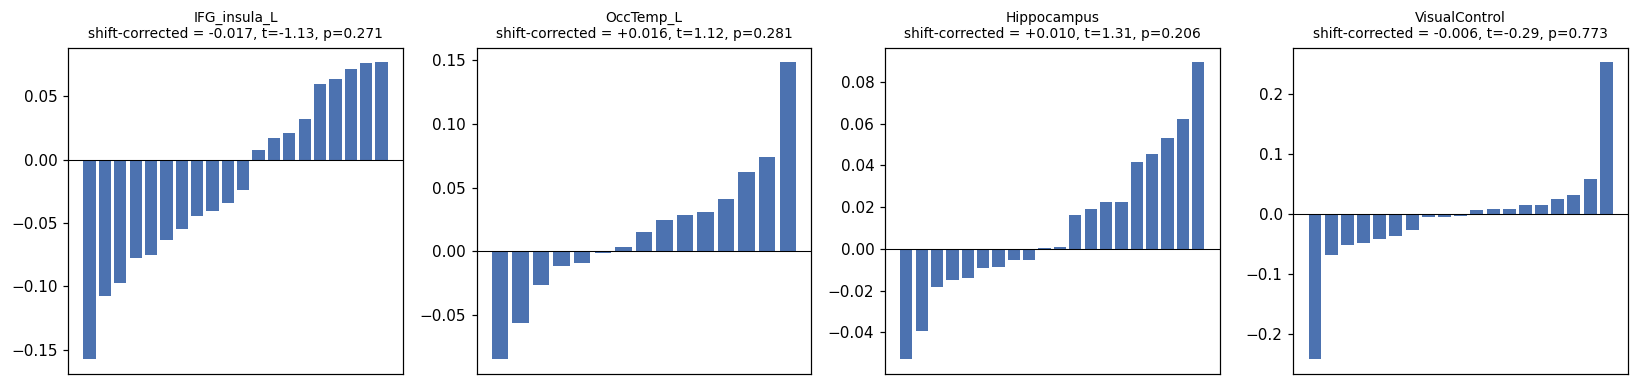

In [21]:
# packaged shift-predictor nulls: 12 random circular shifts per subject/region
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
shift_corr = {}
for ax, r in zip(axes, regions):
    obs  = shifts[f'obsnat__{r}']
    null = shifts[f'shiftnull__{r}']
    corr = obs - null.mean(axis=1)
    okm  = np.isfinite(corr)
    t, pv = ttest_1samp(corr[okm], 0)
    shift_corr[r] = (corr[okm].mean(), t, pv)
    ax.bar(range(okm.sum()), np.sort(corr[okm]), color='#4C72B0')
    ax.axhline(0, c='k', lw=.7)
    ax.set_title(f'{r}\nshift-corrected = {np.nanmean(corr):+.3f}, '
                 f't={t:.2f}, p={pv:.3f}', fontsize=9)
    ax.set_xticks([])
plt.tight_layout();
shift_corr_df = pd.DataFrame(shift_corr, index=['mean', 't', 'p']).T
shift_corr_df

Read that table carefully — it is the most important result of this lab.

Read the two controls together. Lag matching alone: the effect survives in the two cortical regions (IFG p ≈ .01, occipito-temporal p < 10⁻⁴) and nowhere else. The stricter shift predictor then cuts one level deeper — and on this dataset it removes what is left *everywhere*: every region hovers at zero, IFG even dips negative. So the honest summary of our re-analysis is: cortical regions keep a small positive lag-matched effect, but no region's effect passes the shift-predictor test in this lightly-preprocessed data.

The paper, with its full SPM/AFNI preprocessing stack and 20 subjects, reported t(19) = 140 for this contrast — our numbers are far weaker, and the detectable effect depends heavily on preprocessing quality. This is what "replication" actually looks like in fMRI RSA: same direction, same regions, smaller and preprocessing-sensitive magnitudes — with the controls deciding how much of it survives.

### Step 4 — reproduce Figure 4: the group embedding

Average each region's Fisher-z RDM across the 20 subjects, embed with classical MDS (§3), and color by community:


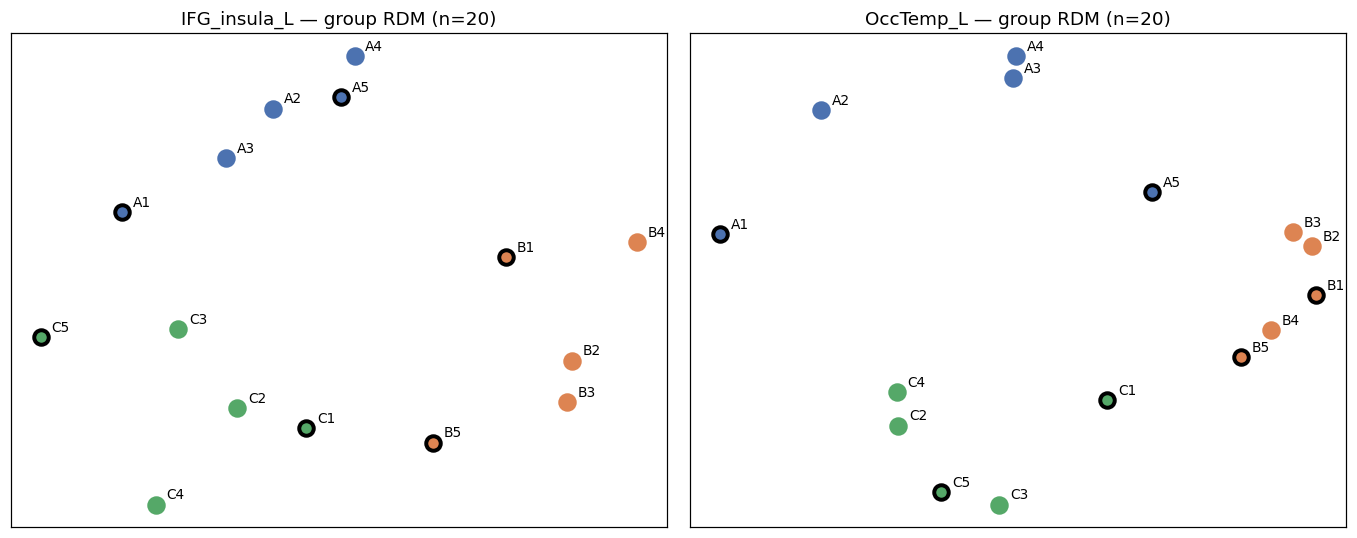

In [22]:
def group_rdm(region):
    return np.nanmean([rdm_fisher(D[f'{region}__{s}']) for s in subjects], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
for ax, r in zip(axes, ['IFG_insula_L', 'OccTemp_L']):
    rG = group_rdm(r)
    rG = (rG + rG.T) / 2; np.fill_diagonal(rG, 0)
    Dm = rG.max() - rG; Dm = (Dm + Dm.T) / 2; np.fill_diagonal(Dm, 0)
    emb = classical_mds(Dm, 2)
    plot_embedding(emb, nodes, title=f'{r} — group RDM (n=20)', ax=ax)
plt.tight_layout();

Left IFG/insula and occipito-temporal cortex both arrange the three
communities into distinguishable sectors, with boundary nodes (black rings)
tending to fall between their neighbours — the geometry the paper reported.

### Step 5 — where in the brain? The whole-brain map

Our whole-brain searchlight t-map (lag-matched statistic, 20 subjects) is
packaged too. Find the clusters and compare them against Table 1 of the
paper:

In [23]:
from scipy import ndimage

tz = np.load('data/week5_schapiro_tmap.npz')
tmap, taff = tz['tmap'], tz['affine']
lab_img, ncl = ndimage.label(tmap > 3.0)
sizes = ndimage.sum(tmap > 3.0, lab_img, range(1, ncl + 1))
order = np.argsort(sizes)[::-1]

print('top clusters (one-sample t across 20 subjects, lag-matched statistic):')
for rank, k in enumerate(order[:5], 1):
    cmask = lab_img == k + 1
    vox = np.array(np.nonzero(cmask)).T
    peak = taff[:3, :3] @ vox[np.argmax(tmap[cmask])].T + taff[:3, 3]
    print(f'  cluster {rank}: {int(sizes[k]):4d} voxels, peak MNI '
          f'[{peak[0]:.0f}, {peak[1]:.0f}, {peak[2]:.0f}]')

print()
print('paper Table 1 (pattern analysis):')
print('  Left IFG, insula and ATL:  [-40, 11, -6], 150 vox')
print('  Left STG:                  [-53, -23, -1], 107 vox')
print('  (their other analyses: mPFC boundary effect [-1, 44, 17];')
print('   IFG/insula + cuneus adaptation effects)')

top clusters (one-sample t across 20 subjects, lag-matched statistic):
  cluster 1: 1192 voxels, peak MNI [-25, -80, -10]
  cluster 2:  819 voxels, peak MNI [-62, -10, 14]
  cluster 3:  581 voxels, peak MNI [-43, 27, 11]
  cluster 4:  548 voxels, peak MNI [2, 59, -2]
  cluster 5:  498 voxels, peak MNI [-23, -73, 49]

paper Table 1 (pattern analysis):
  Left IFG, insula and ATL:  [-40, 11, -6], 150 vox
  Left STG:                  [-53, -23, -1], 107 vox
  (their other analyses: mPFC boundary effect [-1, 44, 17];
   IFG/insula + cuneus adaptation effects)


### Exercise 5 (challenge) — is the group effect real?

The group IFG RDM says yes; a single number can still be luck of the draw. Run a label-permutation test: shuffle which items belong to community A/B/C (keep 5 per community), recompute the lag-matched group statistic 500 times, and compute an exact p-value. Mind the resolution limit: with 500 permutations the smallest reportable p is 1/501 ≈ .002. Bonus: run the same test on the OccTemp_L group RDM — and on VisualControl, where a real effect should *not* appear (region specificity).


In [24]:
# 500 community-label permutations of the group statistic
rng_perm = np.random.default_rng(1)

def lag_from_fz(Fz, pp):
    d = Fz[iu]
    dist = np.abs(pp[iu[0]] - pp[iu[1]])
    ws, bs = [], []
    for dd in (1, 2, 3, 4):
        m = dist == dd
        ws.append(d[m & same].mean()); bs.append(d[m & ~same].mean())
    return np.mean(ws) - np.mean(bs)

# One approximation, stated so you see it: the group RDM pools subjects, but each
# subject followed their own Hamiltonian path -- we lag-match the pooled RDM with
# one subject's path (sub-16). The exact version is Step 3 (per-subject statistics
# with their own paths); the two agree closely here.
for region in ['IFG_insula_L', 'OccTemp_L', 'VisualControl']:
    G = np.nanmean([rdm_fisher(D[f'{region}__{s}']) for s in subjects], axis=0)
    obs = lag_from_fz(G, shifts['pathpos__sub-16'])
    null = []
    for _ in range(500):
        perm = rng_perm.permutation(15)
        null.append(lag_from_fz(G[np.ix_(perm, perm)], shifts['pathpos__sub-16']))
    p_perm = (np.sum(np.array(null) >= obs) + 1) / 501
    print(f'{region:14s} observed = {obs:+.4f}, permutation p = {p_perm:.3f}')


IFG_insula_L   observed = +0.0568, permutation p = 0.034
OccTemp_L      observed = +0.0675, permutation p = 0.008
VisualControl  observed = +0.0062, permutation p = 0.355


## 6. Wrap-up

| | **PCA** | **MDS** |
|---|---|---|
| input | data matrix (N conditions × features) | distance/RDM matrix (N × N) |
| finds | directions of maximal variance | coordinates honoring pairwise distances |
| interpretable output | loadings: feature weights per PC | pure geometry |
| typical failure | curved manifolds fold flat; scaling/outliers dominate | relative structure only, no feature meaning |

Neither method knows what you care about — high variance ≠ informative. When that bites, look to supervised cousins (CVA, classification-based RSA): beyond today.

**What you did today:** hand-rolled PCA and classical MDS ✓ reproduced classic cross-species IT RDMs ✓ built RDMs from real fMRI patterns, implemented the paper's lag-matching control and shift predictor, and reproduced the community embedding of Schapiro et al. — while learning why controls decide whether a correlation means what you think it means ✓.

### Glossary
- **RDM** — representational dissimilarity matrix; N×N distances between activity patterns.
- **RSA** — comparing RDMs (regions, species, models) by correlating their entries.
- **Scree plot** — variance explained per PC; the elbow suggests how many components matter.
- **Classical (Torgerson) MDS** — eigendecomposition of a doubly-centered squared-distance matrix; scikit-learn's `MDS` is the iterative stress-minimizing (SMACOF) cousin.
- **Isomap** — MDS on geodesic (along-manifold) distances; unrolls curved sheets that linear projections fold.
- **events.tsv** — BIDS table of stimulus onsets/durations locking GLM regressors to reality.

### References & credits
- Kriegeskorte, N., Mur, M., Ruff, D., Kiani, R., Bodurka, J., Esteky, H., Tanaka, K., Bandettini, P. (2008). Matching categorical object representations in inferior temporal cortex of man and monkey. *Neuron*. Data © the authors, mirrored via [rsatoolbox](https://github.com/rsagroup/rsatoolbox).
- Derived fMRI patterns: generated from OpenNeuro ds001621 by `make_week5_derived_data.py` (despiking, rigid motion correction, affine MNI normalization, item-pattern extraction per the 2013 Methods). The 2013 searchlight clusters are cortical (left IFG/insula, ATL, STG); hippocampal event representations come from the 2016 *Hippocampus* follow-up.
- Schapiro, A., Rogers, T., Cordova, N., Turk-Browne, N., Botvinick, M. (2013). Neural representations of events arise from temporal community structure. *Nat Neurosci*. Data: OpenNeuro [ds001621](https://openneuro.org/datasets/ds001621).
- Tools: numpy / scipy / matplotlib / scikit-learn; Harvard–Oxford atlas (FSL).

---
## Solutions

Each one folds open. Compare with your own attempt — different numbers can be just as correct.

<details><summary><b>Exercise 1</b></summary>

```python
var_first_two = pca.explained_variance_ratio_[:2].sum()   # ~92%

pcs_2d  = pca.transform(X_blob)[:, :2]
D_after = pdist(pcs_2d)
np.corrcoef(D_before, D_after)[0, 1]     # ≈ 0.99+: geometry essentially intact after 10 -> 2 dims
```
</details>

<details><summary><b>Exercise 2</b></summary>

```python
Z = (P_gain - P_gain.mean(axis=1, keepdims=True)) / P_gain.std(axis=1, keepdims=True)
S_corr = squareform(pdist(Z))      # z-scored Euclidean = sqrt(2 (1 - r)): scale-free
emb_corr = run_mds(S_corr, precomputed=True)
# rerun the two-panel plot with emb_corr: colored by GROUP the three clusters separate;
# colored by GAIN the arrangement collapses into a shapeless cloud.

iu2 = np.triu_indices(n_cond, 1)
D_true = pdist(templates[group_of])     # the structure the data actually contains
print('Euclidean RDM vs true structure:        rho =',
      round(spearmanr(S_euc[iu2], D_true).statistic, 2))     # ~0.4
print('Correlation-distance RDM vs structure:  rho =',
      round(spearmanr(S_corr[iu2], D_true).statistic, 2))    # ~0.85
```

Euclidean distance chases the gain: its map is essentially an ordering by scanner gain (map-vs-gain r ≈ 0.9, map-vs-group r ≈ 0.2) and its RDM barely tracks the real structure. Correlation distance ignores overall magnitude, so the gain cancels and the map recovers the three groups.

For multi-session fMRI: prefer correlation distance — it absorbs gain drift.

</details>


<details><summary><b>Exercise 3</b></summary>

```python
within_f, between_f = rdm_within_between(hIT_rdm, mask_face)
# faces are MORE similar to each other than to everything else;
# if categories were irrelevant both numbers would equal the grand mean (≈ 0.85 here).
```
</details>

<details><summary><b>Exercise 4</b></summary>

```python
for name, rdm in targets.items():
    rsa_scores[name] = spearmanr(hIT_rdm[iu], rdm[iu]).statistic
pd.Series(rsa_scores).sort_values().plot.barh()
# Expected: animacy & FaceBodyManmadeNatobj up top; monkey IT strong; Silhouette/V1 near zero.
```
</details>

<details><summary><b>Exercise 5</b></summary>

```python
# same loop as the cell above, pointed at each region's group RDM
# Expected on the shipped data (deterministic given the seed): IFG_insula_L
# p ≈ .03, OccTemp_L p ≈ .008 -- real but unimpressive, the preprocessing-
# sensitive effect sizes discussed in Step 3 -- and VisualControl at chance
# (p ≈ .36): the effect is not region-specific once you look in visual cortex.
# With 500 permutations the smallest reportable p is 1/501 ≈ .002, so a fitted
# 'p < .001' is not a sentence this test can produce.
```
</details>
